In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask

# -----------------------
# Config / paths (same as before)
# -----------------------
path_params = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"

# -----------------------
# Paths
# -----------------------
path_txx   = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config (same as your plot)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Other box (example you had)
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load datasets
# -----------------------
ds_txx    = xr.open_dataset(path_txx).sortby("lon")

# -----------------------
# 2) Apply same lat band
# -----------------------
ds_band    = sel_lat_band(ds_txx,   lat_min, lat_max)

# -----------------------
# 1) Load saved GEV parameter file (event_max fit excl per-cell max)
# -----------------------
ds_params = xr.open_dataset(path_params).sortby("lon")
c     = -ds_params["gev_shape_c"]
loc   = ds_params["gev_loc"]
scale = ds_params["gev_scale"]

# -----------------------
# 2) Build target field: t500_premax_3d at hottest TXX (per grid cell)
#    (same dataset objects as your return-period script)
# -----------------------
# ds_band is already lat-banded in your script; just ensure lon sorted
ds_band = ds_band.sortby("lon")

# robust-ish: pick txx from ds_band
if "txx" in ds_band.data_vars:
    txx = ds_band["txx"]
elif "TXX" in ds_band.data_vars:
    txx = ds_band["TXX"]
else:
    txx = ds_band[list(ds_band.data_vars)[0]]

# identify time dim (your script assumes year)
time_dim = "year" if "year" in txx.dims else "time"

# index of hottest TXX per grid cell
i_hot = txx.argmax(time_dim, skipna=True)  # (lat, lon)

# T500 pre-day max at that timestep per grid cell
t500_hot = ds_band["t500_premax_3d"].isel({time_dim: i_hot})  # (lat, lon)

# -----------------------
# 3) Land mask (same approach as before)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

t500_hot_land = t500_hot.where(land_mask)

# -----------------------
# 4) Compute finite upper endpoint + distance
# -----------------------
# Align grids (safe)
cA, locA, scaleA, t500A = xr.align(c, loc, scale, t500_hot_land, join="inner")

# finite upper endpoint exists only for c < 0
upper_endpoint = xr.where(cA < 0, locA - (scaleA / cA), np.nan)

# distance to upper endpoint
dist_to_upper = upper_endpoint - t500A

In [2]:
# -----------------------
# 4) Compute finite GEV upper endpoint
#    and convert it to 500 hPa potential temperature
#    using mean surface pressure per grid cell
# -----------------------

# Mean surface pressure at tasmax per grid cell
sp_mean = ds_band["sp_at_tasmax"].mean(time_dim, skipna=True)

# Convert Pa -> hPa if needed
sp_mean_hpa = xr.where(sp_mean > 2000, sp_mean / 100.0, sp_mean)

# Align with endpoint field
upper_endpoint_T500, t500A, spA = xr.align(
    upper_endpoint, t500A, sp_mean_hpa, join="inner"
)

# Potential temperature using grid-cell mean surface pressure as reference pressure
p500 = 500.0  # hPa
kappa = 0.286

upper_endpoint_theta500 = upper_endpoint_T500 * (spA / p500) ** kappa
theta500_hot = t500A * (spA / p500) ** kappa

# Distance to upper endpoint in theta500 space
dist_to_upper = upper_endpoint_theta500 - theta500_hot

# Keep only non-negative distances
dist_to_upper = dist_to_upper#.where(dist_to_upper >= 0)

In [3]:
import numpy as np
import xarray as xr
from scipy.stats import genextreme
from scipy.optimize import minimize


def fit_gev_with_upper_bound_1d(data, U):
    """
    Fit GEV to 1D TXx data with fixed upper endpoint U.

    SciPy convention:
        upper endpoint = loc + scale / c
        requires c > 0
    """

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if data.size < 10:
        return np.nan, np.nan, np.nan, np.nan

    if not np.isfinite(U):
        return np.nan, np.nan, np.nan, np.nan

    # all fitted data must be strictly below imposed upper endpoint
    data = data[data < U]

    if data.size < 10:
        return np.nan, np.nan, np.nan, np.nan

    def nll(params):
        c, scale = params

        if c <= 0 or scale <= 0:
            return np.inf

        loc = U - scale / c

        logpdf = genextreme.logpdf(data, c=c, loc=loc, scale=scale)

        if not np.all(np.isfinite(logpdf)):
            return np.inf

        return -np.sum(logpdf)

    x0 = [0.2, 0.5 * np.nanstd(data)]

    res = minimize(
        nll,
        x0=x0,
        bounds=[(1e-3, 5.0), (1e-8, None)],
        method="L-BFGS-B"
    )

    if not res.success:
        return np.nan, np.nan, np.nan, np.nan

    c, scale = res.x
    loc = U - scale / c
    upper_endpoint = loc + scale / c

    return c, loc, scale, upper_endpoint

import numpy as np
from scipy.optimize import minimize


def fit_gev_with_upper_bound_1d_fast(data, U):
    """
    Faster GEV fit with fixed upper endpoint U.

    SciPy convention:
        upper endpoint = loc + scale / c
        c > 0

    Parameters fitted:
        log_c, log_scale
    """

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if data.size < 10:
        return np.nan, np.nan, np.nan, np.nan

    if not np.isfinite(U):
        return np.nan, np.nan, np.nan, np.nan

    # important: do NOT silently drop exceedances
    if np.nanmax(data) >= U:
        return np.nan, np.nan, np.nan, np.nan

    n = data.size

    def nll(theta):
        log_c, log_scale = theta

        c = np.exp(log_c)
        scale = np.exp(log_scale)

        loc = U - scale / c

        z = (data - loc) / scale
        y = 1.0 - c * z

        # support condition
        if np.any(y <= 0):
            return 1e100

        # SciPy genextreme logpdf:
        # log f = -log(scale) + (1/c - 1) * log(y) - y**(1/c)
        logy = np.log(y)
        invc = 1.0 / c

        return n * log_scale - np.sum((invc - 1.0) * logy - y**invc)

    # better starting values
    std = np.nanstd(data)
    if not np.isfinite(std) or std <= 0:
        return np.nan, np.nan, np.nan, np.nan

    x0 = np.array([
        np.log(0.2),          # c
        np.log(0.5 * std),    # scale
    ])

    res = minimize(
        nll,
        x0=x0,
        method="Nelder-Mead",
        options={
            "maxiter": 200,
            "xatol": 1e-4,
            "fatol": 1e-4,
            "disp": False,
        },
    )

    if not res.success:
        return np.nan, np.nan, np.nan, np.nan

    log_c, log_scale = res.x
    c = np.exp(log_c)
    scale = np.exp(log_scale)

    if c <= 0 or scale <= 0:
        return np.nan, np.nan, np.nan, np.nan

    loc = U - scale / c
    upper_endpoint = loc + scale / c

    return c, loc, scale, upper_endpoint

In [4]:
import dask.array as da
from dask.diagnostics import ProgressBar

# -----------------------
# Dask-based spatial parallel fit
# input TXx already excludes per-gridcell maximum
# -----------------------

txxA, upperA = xr.align(txx, upper_endpoint_theta500, join="inner")

# Exclude the single TXx maximum per grid cell
txx_max = txxA.max(time_dim, skipna=True)
txx_exclmax = txxA.where(txxA < txx_max)

# Chunk after masking
txx_exclmax = txx_exclmax.chunk({time_dim: -1, "lat": 80, "lon": 80})
upperA = upperA.chunk({"lat": 80, "lon": 80})

fit_params = xr.apply_ufunc(
    fit_gev_with_upper_bound_1d_fast,
    txx_exclmax,
    upperA,
    input_core_dims=[[time_dim], []],
    output_core_dims=[[], [], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float, float],
    dask_gufunc_kwargs={
        "allow_rechunk": False,
    },
)

gev_shape_c, gev_loc, gev_scale, gev_upper_endpoint = fit_params

ds_fit_bounded = xr.Dataset(
    {
        "gev_shape_c": gev_shape_c,
        "gev_loc": gev_loc,
        "gev_scale": gev_scale,
        "gev_upper_endpoint": gev_upper_endpoint,
        "upper_bound_used": upperA,
        "txx_max_excluded": txx_max,
    }
)

# -----------------------
# Trigger computation WITH progress bar
# -----------------------

with ProgressBar():
    ds_fit_bounded.to_netcdf(
        "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
        "gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
    )

[########################################] | 100% Completed | 12min  4.9s


Max TXx: 314.1802
Upper bound: 326.27412136350745
Excluded max TXx: 314.1802


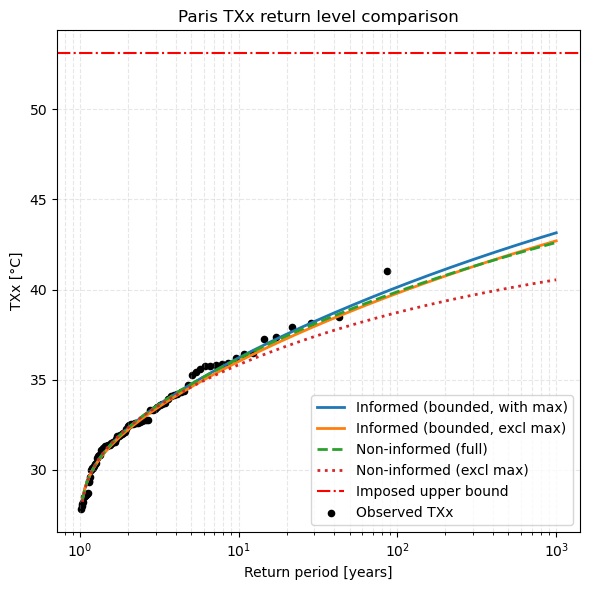


Informed (bounded, excl max):
c = 0.10652886303644743 loc = 304.52101078841105 scale = 2.3173341370711382

Non-informed (full):
c = 0.12366828750894458 loc = 304.6014815793043 scale = 2.4024187523508855

Non-informed (excl max):
c = 0.1940413381428599 loc = 304.6315652871316 scale = 2.3810395022261615


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
import xarray as xr

ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound.nc"
)

# -----------------------
# Define Paris coordinates
# -----------------------
lat_paris = 48.86
lon_paris = 2.35

# -----------------------
# Extract Paris data
# -----------------------
txx_paris = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris = ds_fit_boundeds.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris2 = ds_fit_boundeds2.sel(lat=lat_paris, lon=lon_paris, method="nearest")

# bounded / informed fit (already excl max)
c_b = float(fit_paris["gev_shape_c"])
loc_b = float(fit_paris["gev_loc"])
scale_b = float(fit_paris["gev_scale"])
U = float(fit_paris["upper_bound_used"])

c_b2 = float(fit_paris2["gev_shape_c"])
loc_b2 = float(fit_paris2["gev_loc"])
scale_b2 = float(fit_paris2["gev_scale"])
U2 = float(fit_paris2["upper_bound_used"])

data = txx_paris.values
data = data[np.isfinite(data)]

print("Max TXx:", np.max(data))
print("Upper bound:", U)

# -----------------------
# Non-informed GEV (FULL data)
# -----------------------
c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

# -----------------------
# Non-informed GEV (EXCLUDING max)
# -----------------------
data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

print("Excluded max TXx:", max_val)

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(data_excl)

# -----------------------
# Return level curves
# -----------------------
T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(c=c_b, loc=loc_b, scale=scale_b)
gev_bounded2 = genextreme(c=c_b2, loc=loc_b2, scale=scale_b2)
gev_free_full = genextreme(c=c_free_full, loc=loc_free_full, scale=scale_free_full)
gev_free_excl = genextreme(c=c_free_excl, loc=loc_free_excl, scale=scale_free_excl)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

# -----------------------
# Empirical return periods
# -----------------------
data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6, 6))

plt.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=2, alpha = 1,
    label="Informed (bounded, with max)"
)

plt.plot(
    T, x_T_bounded - 273.15,
    linewidth=2, alpha = 1,
    label="Informed (bounded, excl max)"
)

plt.plot(
    T, x_T_free_full - 273.15,
    linewidth=2,
    linestyle="--",
    label="Non-informed (full)"
)

plt.plot(
    T, x_T_free_excl - 273.15,
    linewidth=2,
    linestyle=":",
    label="Non-informed (excl max)"
)

plt.scatter(
    T_emp, data_sorted - 273.15,
    color="black",
    s=20,
    label="Observed TXx"
)

plt.axhline(
    U - 273.15,
    color="red",
    linestyle="-.",
    label="Imposed upper bound"
)

plt.xscale("log")
plt.xlabel("Return period [years]")
plt.ylabel("TXx [°C]")

plt.title("Paris TXx return level comparison")
plt.legend()

plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------
# Print parameters
# -----------------------
print("\nInformed (bounded, excl max):")
print("c =", c_b, "loc =", loc_b, "scale =", scale_b)

print("\nNon-informed (full):")
print("c =", c_free_full, "loc =", loc_free_full, "scale =", scale_free_full)

print("\nNon-informed (excl max):")
print("c =", c_free_excl, "loc =", loc_free_excl, "scale =", scale_free_excl)

In [69]:
fit_lytton

<xarray.Dataset>
Dimensions:             ()
Coordinates:
    lon                 float64 238.5
    lat                 float64 50.16
    plev                float64 5e+04
Data variables:
    gev_shape_c         float64 nan
    gev_loc             float64 nan
    gev_scale           float64 nan
    gev_upper_endpoint  float64 nan
    upper_bound_used    float64 320.4
    txx_max_excluded    float32 309.6

Nearest grid point:
50.16391349937449 238.78125
Max TXx: 311.42706
Upper bound: 322.0105962914074
Excluded max TXx: 311.42706


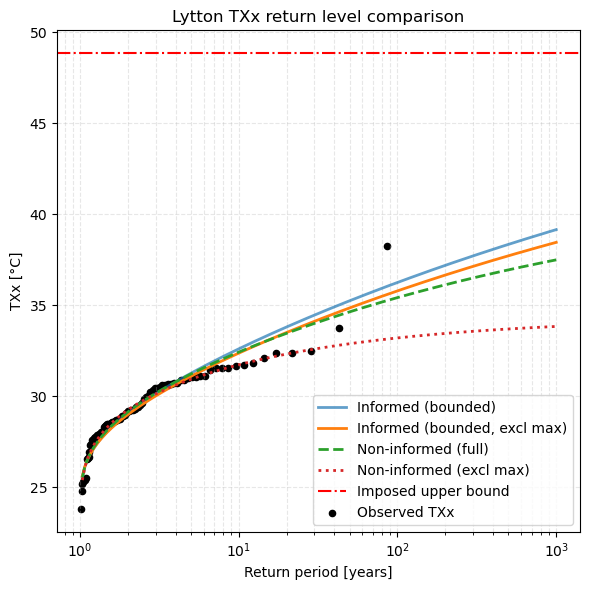


Informed (bounded, excl max):
c = 0.09898881114819594 loc = 301.41770189263315 scale = 2.0384661346350064

Non-informed (full):
c = 0.15015303042038766 loc = 301.53684370236715 scale = 2.120876214227012

Non-informed (excl max):
c = 0.3560408660168544 loc = 301.69770248289933 scale = 2.0630382375500513


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
import xarray as xr

ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)


ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound.nc"
)

# -----------------------
# Define Lytton coordinates
# -----------------------
lat_lytton = 50.23
lon_lytton = 360 - 121.58+0.25  # 238.42 for 0–360 longitude grids

# -----------------------
# Extract Lytton data
# -----------------------
txx_lytton = txx.sel(lat=lat_lytton, lon=lon_lytton, method="nearest")
fit_lytton = ds_fit_boundeds.sel(lat=lat_lytton, lon=lon_lytton, method="nearest")
fit_lytton2 = ds_fit_boundeds2.sel(lat=lat_lytton, lon=lon_lytton, method="nearest")


# bounded / informed fit
c_b = float(fit_lytton["gev_shape_c"])
loc_b = float(fit_lytton["gev_loc"])
scale_b = float(fit_lytton["gev_scale"])
U = float(fit_lytton["upper_bound_used"])

c_b2 = float(fit_lytton2["gev_shape_c"])
loc_b2 = float(fit_lytton2["gev_loc"])
scale_b2 = float(fit_lytton2["gev_scale"])
U2 = float(fit_lytton2["upper_bound_used"])

data = txx_lytton.values
data = data[np.isfinite(data)]

print("Nearest grid point:")
print(float(txx_lytton.lat), float(txx_lytton.lon))
print("Max TXx:", np.max(data))
print("Upper bound:", U)

# -----------------------
# Non-informed GEV full data
# -----------------------
c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

# -----------------------
# Non-informed GEV excluding max
# -----------------------
data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

print("Excluded max TXx:", max_val)

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(data_excl)

# -----------------------
# Return level curves
# -----------------------
T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(c=c_b, loc=loc_b, scale=scale_b)
gev_bounded2 = genextreme(c=c_b2, loc=loc_b2, scale=scale_b2)
gev_free_full = genextreme(c=c_free_full, loc=loc_free_full, scale=scale_free_full)
gev_free_excl = genextreme(c=c_free_excl, loc=loc_free_excl, scale=scale_free_excl)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

# -----------------------
# Empirical return periods
# -----------------------
data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6, 6))

plt.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=2, alpha = 0.7,
    label="Informed (bounded)"
)

plt.plot(
    T, x_T_bounded - 273.15,
    linewidth=2,
    label="Informed (bounded, excl max)"
)

plt.plot(
    T, x_T_free_full - 273.15,
    linewidth=2,
    linestyle="--",
    label="Non-informed (full)"
)

plt.plot(
    T, x_T_free_excl - 273.15,
    linewidth=2,
    linestyle=":",
    label="Non-informed (excl max)"
)

plt.scatter(
    T_emp, data_sorted - 273.15,
    color="black",
    s=20,
    label="Observed TXx"
)

plt.axhline(
    U - 273.15,
    color="red",
    linestyle="-.",
    label="Imposed upper bound"
)

plt.xscale("log")
plt.xlabel("Return period [years]")
plt.ylabel("TXx [°C]")

plt.title("Lytton TXx return level comparison")
plt.legend()

plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------
# Print parameters
# -----------------------
print("\nInformed (bounded, excl max):")
print("c =", c_b, "loc =", loc_b, "scale =", scale_b)

print("\nNon-informed (full):")
print("c =", c_free_full, "loc =", loc_free_full, "scale =", scale_free_full)

print("\nNon-informed (excl max):")
print("c =", c_free_excl, "loc =", loc_free_excl, "scale =", scale_free_excl)

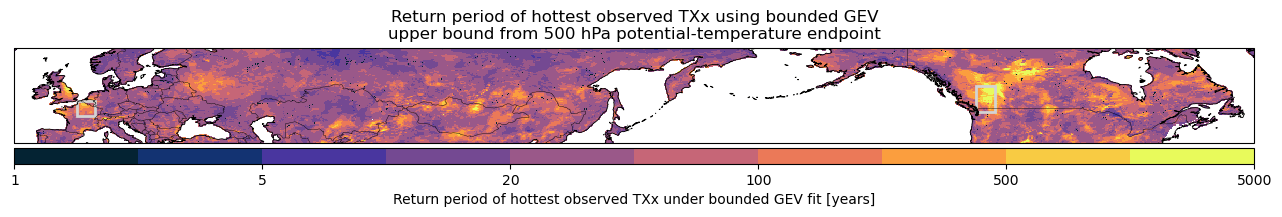

In [14]:
from scipy.stats import genextreme
import numpy as np

# -----------------------
# Return period of hottest observed TXx
# using bounded GEV fit excluding max
# -----------------------

ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound.nc"
)

# Align data and fitted params
txxA, cA, locA, scaleA = xr.align(
    txx,
    ds_fit_boundeds["gev_shape_c"],
    ds_fit_boundeds["gev_loc"],
    ds_fit_boundeds["gev_scale"],
    join="inner"
)

# Hottest observed TXx per grid cell
txx_hot = txxA.max(time_dim, skipna=True)

def gev_return_period_1d(x, c, loc, scale):
    if not np.all(np.isfinite([x, c, loc, scale])):
        return np.nan

    if scale <= 0:
        return np.nan

    F = genextreme.cdf(x, c=c, loc=loc, scale=scale)

    if not np.isfinite(F):
        return np.nan

    p_exceed = 1.0 - F

    if p_exceed <= 0:
        return np.inf

    return 1.0 / p_exceed


return_period_hot = xr.apply_ufunc(
    gev_return_period_1d,
    txx_hot,
    cA,
    locA,
    scaleA,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

# Plot-friendly cap
return_period_plot = return_period_hot.where(np.isfinite(return_period_hot))
return_period_plot = return_period_plot.clip(max=1000)
# -----------------------
# Plot return period map
# -----------------------

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

levels = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000,5000])

im = return_period_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=levels,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80,
)

cbar.set_label("Return period of hottest observed TXx under bounded GEV fit [years]")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title(
    "Return period of hottest observed TXx using bounded GEV\n"
    "upper bound from 500 hPa potential-temperature endpoint"
)

fig.subplots_adjust(bottom=0.22)

plt.savefig(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "RP_hottest_TXX_boundedGEV_t500theta_upperbound.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

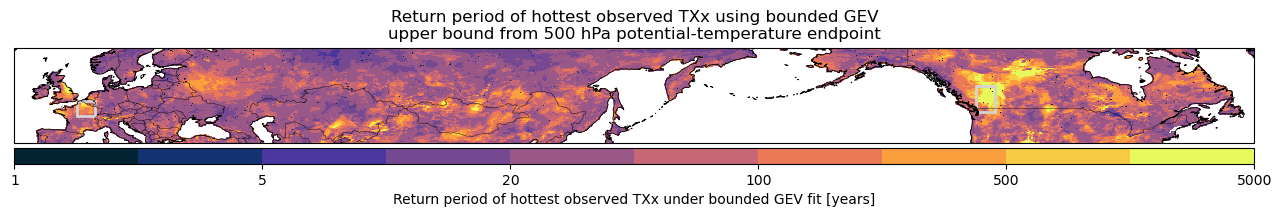

In [15]:
from scipy.stats import genextreme
import numpy as np

# -----------------------
# Return period of hottest observed TXx
# using bounded GEV fit excluding max
# -----------------------

ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

# Align data and fitted params
txxA, cA, locA, scaleA = xr.align(
    txx,
    ds_fit_boundeds["gev_shape_c"],
    ds_fit_boundeds["gev_loc"],
    ds_fit_boundeds["gev_scale"],
    join="inner"
)

# Hottest observed TXx per grid cell
txx_hot = txxA.max(time_dim, skipna=True)

def gev_return_period_1d(x, c, loc, scale):
    if not np.all(np.isfinite([x, c, loc, scale])):
        return np.nan

    if scale <= 0:
        return np.nan

    F = genextreme.cdf(x, c=c, loc=loc, scale=scale)

    if not np.isfinite(F):
        return np.nan

    p_exceed = 1.0 - F

    if p_exceed <= 0:
        return np.inf

    return 1.0 / p_exceed


return_period_hot = xr.apply_ufunc(
    gev_return_period_1d,
    txx_hot,
    cA,
    locA,
    scaleA,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

# Plot-friendly cap
return_period_plot = return_period_hot.where(np.isfinite(return_period_hot))
return_period_plot = return_period_plot.clip(max=1000)
# -----------------------
# Plot return period map
# -----------------------

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

levels = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000,5000])

im = return_period_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=levels,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80,
)

cbar.set_label("Return period of hottest observed TXx under bounded GEV fit [years]")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title(
    "Return period of hottest observed TXx using bounded GEV\n"
    "upper bound from 500 hPa potential-temperature endpoint"
)

fig.subplots_adjust(bottom=0.22)

plt.savefig(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "RP_hottest_TXX_boundedGEV_t500theta_upperbound_exclmax.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Done computing partial-correlation significance mask


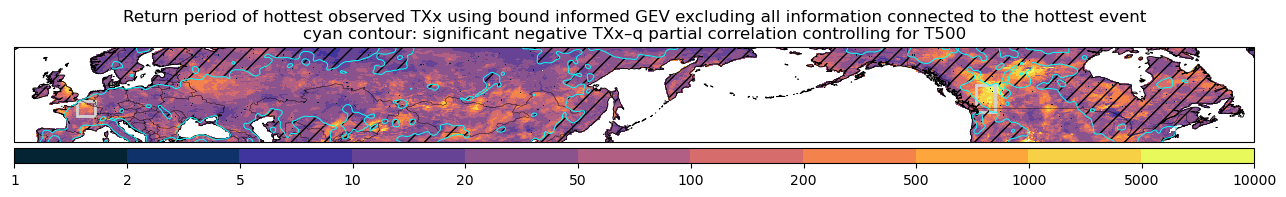

In [41]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask
from scipy.stats import genextreme
from scipy.ndimage import gaussian_filter

# ======================================================
# Paths
# ======================================================

path_txx = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "txx_at_tasmax_merged_1940_2024.nc"
)

path_fit_bounded = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

path_null = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "random_q_null_partial_correlations/"
    "partial_corr_txx_random_q_all_realizations.nc"
)

# ======================================================
# Config
# ======================================================

lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Lytton box
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# ======================================================
# 1) Load TXx dataset
# ======================================================

ds = xr.open_dataset(path_txx).sortby("lon")
ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

txx = ds_band["txx"]
q = ds_band["q_at_tasmax"]
t500 = ds_band["t500_premax_3d"]

time_dim = "year" if "year" in txx.dims else "time"

txx, q, t500 = xr.align(txx, q, t500, join="inner")

# ======================================================
# 2) Partial correlation significance mask
# ======================================================

min_n = 20

valid = np.isfinite(txx) & np.isfinite(q) & np.isfinite(t500)
nvalid = valid.sum(time_dim)

txx_valid = txx.where(valid).where(nvalid >= min_n)
q_valid = q.where(valid).where(nvalid >= min_n)
t500_valid = t500.where(valid).where(nvalid >= min_n)

r_txx_q = xr.corr(txx_valid, q_valid, dim=time_dim)
r_txx_t500 = xr.corr(txx_valid, t500_valid, dim=time_dim)
r_q_t500 = xr.corr(q_valid, t500_valid, dim=time_dim)

r_obs = (
    (r_txx_q - r_txx_t500 * r_q_t500)
    / np.sqrt((1 - r_txx_t500**2) * (1 - r_q_t500**2))
)

r_obs = r_obs.where(np.isfinite(r_obs))

# Land mask
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_band["lon"],
    ds_band["lat"],
    wrap_lon=True
) == 0

r_obs = r_obs.where(land_mask)

# Load null partial correlations
ds_null = xr.open_dataset(path_null)

if "realization" in ds_null.dims and ds_null.sizes["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.sizes["realization"])
)

r_null = ds_null["r_partial_txx_random_q_control_t500"]
r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

r_obs, r_null_band, land_mask = xr.align(
    r_obs,
    r_null_band,
    land_mask,
    join="inner"
)

# Two-sided empirical p-value against random-q null
p_value = (
    np.abs(r_null_band) >= np.abs(r_obs)
).mean("realization")

sig_mask = (
    (p_value < 0.05)
    & (r_obs < 0)
    & land_mask
    & np.isfinite(r_obs)
)

sig_mask = sig_mask.fillna(False)

print("Done computing partial-correlation significance mask")

# ======================================================
# 3) Return period of hottest observed TXx
#    under bounded GEV fit excluding max
# ======================================================

ds_fit_boundeds = xr.open_dataset(path_fit_bounded).sortby("lon")

txxA, cA, locA, scaleA = xr.align(
    txx,
    ds_fit_boundeds["gev_shape_c"],
    ds_fit_boundeds["gev_loc"],
    ds_fit_boundeds["gev_scale"],
    join="inner"
)

txx_hot = txxA.max(time_dim, skipna=True)

def gev_return_period_1d(x, c, loc, scale):
    if not np.all(np.isfinite([x, c, loc, scale])):
        return np.nan

    if scale <= 0:
        return np.nan

    F = genextreme.cdf(x, c=c, loc=loc, scale=scale)

    if not np.isfinite(F):
        return np.nan

    p_exceed = 1.0 - F

    if p_exceed <= 0:
        return np.inf

    return 1.0 / p_exceed

return_period_hot = xr.apply_ufunc(
    gev_return_period_1d,
    txx_hot,
    cA,
    locA,
    scaleA,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

return_period_plot = return_period_hot.where(np.isfinite(return_period_hot))
return_period_plot = return_period_plot.clip(max=5000)

# Align significance mask with return-period field
return_period_plot, sig_mask_rp = xr.align(
    return_period_plot,
    sig_mask,
    join="inner"
)

sig_mask_rp = sig_mask_rp.fillna(False)

# ======================================================
# 4) Plot return period map with yellow significance contour
# ======================================================

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

levels = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 5000, 10000])

im = return_period_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=levels,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

# Bright yellow contour around significant/stippled regions
# -----------------------
# Smooth significance mask
# -----------------------

sig_float = sig_mask_rp.astype(float)

# apply Gaussian smoothing (tune sigma)
sig_smooth = xr.apply_ufunc(
    gaussian_filter,
    sig_float,
    kwargs={"sigma": 2},
    dask="parallelized",
    output_dtypes=[float],
)

# -----------------------
# Plot smoothed contour
# -----------------------

sig_smooth.plot.contour(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=[0.5],
    colors="cyan",
    linewidths=0.7,
    add_labels=False,
    zorder=10
)

# -----------------------
# Add stripes ONLY outside smoothed significant region
# -----------------------

inside_smooth = sig_smooth >= 0.5

# align masks
inside_smooth, return_period_plot, land_mask = xr.align(
    inside_smooth,
    return_period_plot,
    land_mask,
    join="inner"
)

outside_smooth = (
    (~inside_smooth)
    & land_mask
    & np.isfinite(return_period_plot)
)

# IMPORTANT: mask everything else with NaN
outside_hatch = xr.where(outside_smooth, 1.0, np.nan)

outside_hatch.plot.contourf(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=[0.5, 1.5],
    colors="none",
    hatches=["//"],
    add_colorbar=False,
    zorder=8,
)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80,
    ticks=levels, 
)

#cbar.set_label(
#    "Return period of hottest observed TXx under bounded GEV fit [years]"
#)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title(
    "Return period of hottest observed TXx using bound informed GEV excluding all information connected to the hottest event\n"
    "cyan contour: significant negative TXx–q partial correlation controlling for T500"
)

fig.subplots_adjust(bottom=0.22)

plt.savefig(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "RP_hottest_TXX_boundedGEV_with_partialcorr_yellow_contour_exclmax.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ds.close()
ds_null.close()
ds_fit_boundeds.close()

Done computing partial-correlation significance mask


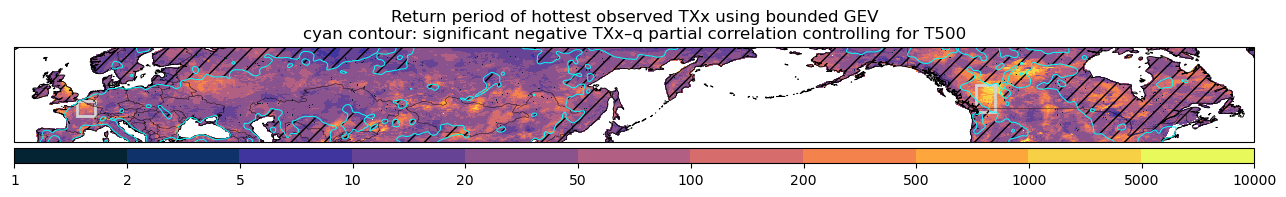

In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask
from scipy.stats import genextreme
from scipy.ndimage import gaussian_filter

# ======================================================
# Paths
# ======================================================

path_txx = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "txx_at_tasmax_merged_1940_2024.nc"
)

path_fit_bounded = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound.nc"
)

path_null = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "random_q_null_partial_correlations/"
    "partial_corr_txx_random_q_all_realizations.nc"
)

# ======================================================
# Config
# ======================================================

lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Lytton box
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# ======================================================
# 1) Load TXx dataset
# ======================================================

ds = xr.open_dataset(path_txx).sortby("lon")
ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

txx = ds_band["txx"]
q = ds_band["q_at_tasmax"]
t500 = ds_band["t500_premax_3d"]

time_dim = "year" if "year" in txx.dims else "time"

txx, q, t500 = xr.align(txx, q, t500, join="inner")

# ======================================================
# 2) Partial correlation significance mask
# ======================================================

min_n = 20

valid = np.isfinite(txx) & np.isfinite(q) & np.isfinite(t500)
nvalid = valid.sum(time_dim)

txx_valid = txx.where(valid).where(nvalid >= min_n)
q_valid = q.where(valid).where(nvalid >= min_n)
t500_valid = t500.where(valid).where(nvalid >= min_n)

r_txx_q = xr.corr(txx_valid, q_valid, dim=time_dim)
r_txx_t500 = xr.corr(txx_valid, t500_valid, dim=time_dim)
r_q_t500 = xr.corr(q_valid, t500_valid, dim=time_dim)

r_obs = (
    (r_txx_q - r_txx_t500 * r_q_t500)
    / np.sqrt((1 - r_txx_t500**2) * (1 - r_q_t500**2))
)

r_obs = r_obs.where(np.isfinite(r_obs))

# Land mask
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_band["lon"],
    ds_band["lat"],
    wrap_lon=True
) == 0

r_obs = r_obs.where(land_mask)

# Load null partial correlations
ds_null = xr.open_dataset(path_null)

if "realization" in ds_null.dims and ds_null.sizes["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.sizes["realization"])
)

r_null = ds_null["r_partial_txx_random_q_control_t500"]
r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

r_obs, r_null_band, land_mask = xr.align(
    r_obs,
    r_null_band,
    land_mask,
    join="inner"
)

# Two-sided empirical p-value against random-q null
p_value = (
    np.abs(r_null_band) >= np.abs(r_obs)
).mean("realization")

sig_mask = (
    (p_value < 0.05)
    & (r_obs < 0)
    & land_mask
    & np.isfinite(r_obs)
)

sig_mask = sig_mask.fillna(False)

print("Done computing partial-correlation significance mask")

# ======================================================
# 3) Return period of hottest observed TXx
#    under bounded GEV fit excluding max
# ======================================================

ds_fit_boundeds = xr.open_dataset(path_fit_bounded).sortby("lon")

txxA, cA, locA, scaleA = xr.align(
    txx,
    ds_fit_boundeds["gev_shape_c"],
    ds_fit_boundeds["gev_loc"],
    ds_fit_boundeds["gev_scale"],
    join="inner"
)

txx_hot = txxA.max(time_dim, skipna=True)

def gev_return_period_1d(x, c, loc, scale):
    if not np.all(np.isfinite([x, c, loc, scale])):
        return np.nan

    if scale <= 0:
        return np.nan

    F = genextreme.cdf(x, c=c, loc=loc, scale=scale)

    if not np.isfinite(F):
        return np.nan

    p_exceed = 1.0 - F

    if p_exceed <= 0:
        return np.inf

    return 1.0 / p_exceed

return_period_hot = xr.apply_ufunc(
    gev_return_period_1d,
    txx_hot,
    cA,
    locA,
    scaleA,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

return_period_plot = return_period_hot.where(np.isfinite(return_period_hot))
return_period_plot = return_period_plot.clip(max=5000)

# Align significance mask with return-period field
return_period_plot, sig_mask_rp = xr.align(
    return_period_plot,
    sig_mask,
    join="inner"
)

sig_mask_rp = sig_mask_rp.fillna(False)

# ======================================================
# 4) Plot return period map with yellow significance contour
# ======================================================

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

levels = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 5000, 10000])

im = return_period_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=levels,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

# Bright yellow contour around significant/stippled regions
# -----------------------
# Smooth significance mask
# -----------------------

sig_float = sig_mask_rp.astype(float)

# apply Gaussian smoothing (tune sigma)
sig_smooth = xr.apply_ufunc(
    gaussian_filter,
    sig_float,
    kwargs={"sigma": 2},
    dask="parallelized",
    output_dtypes=[float],
)

# -----------------------
# Plot smoothed contour
# -----------------------

sig_smooth.plot.contour(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=[0.5],
    colors="cyan",
    linewidths=0.7,
    add_labels=False,
    zorder=10
)

# -----------------------
# Add stripes ONLY outside smoothed significant region
# -----------------------

inside_smooth = sig_smooth >= 0.5

# align masks
inside_smooth, return_period_plot, land_mask = xr.align(
    inside_smooth,
    return_period_plot,
    land_mask,
    join="inner"
)

outside_smooth = (
    (~inside_smooth)
    & land_mask
    & np.isfinite(return_period_plot)
)

# IMPORTANT: mask everything else with NaN
outside_hatch = xr.where(outside_smooth, 1.0, np.nan)

outside_hatch.plot.contourf(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    levels=[0.5, 1.5],
    colors="none",
    hatches=["//"],
    add_colorbar=False,
    zorder=8
)
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80,
    ticks=levels, 
)

#cbar.set_label(
#    "Return period of hottest observed TXx under bounded GEV fit [years]"
#)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title(
    "Return period of hottest observed TXx using bounded GEV\n"
    "cyan contour: significant negative TXx–q partial correlation controlling for T500"
)

fig.subplots_adjust(bottom=0.22)

plt.savefig(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "RP_hottest_TXX_boundedGEV_with_partialcorr_yellow_contour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ds.close()
ds_null.close()
ds_fit_boundeds.close()

In [49]:
c_b

nan